<a href="https://colab.research.google.com/github/debbie-dotcom/my-capstone-project/blob/main/my_capstone_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Title: TOMATO PRICE VOLATILITY IN NIGERIA

# Brief Introduction: Tomato is an important  vegetable crop  facing  extreme  price  volatility  in  Nigeria  with increasing prices at consumers end and non-remunerative prices at producers' end. ARCH/GARCH  models are employed to identify price volatility and seasonal variations in some selected store locations.  Tomato Price Volatility means how much the price of tomato moves up and down in the market. It measures risk, uncertainty and trading opportunities. It is also characterized by intense volatility clustering, meaning periods of large price swings are followed by more large swings, and calm periods follow calm periods.

The objective of the project was  aimed at  analysing volatility, and  seasonal variation  in prices  of tomato using ARCH/GARCH models. ARCH(Auto regressive Conditional Heteroskeasticity models volatility using past squared returns i.e if yesterday's returns on tomato was very large, today's volatility will be high. Likewise Garch generalized arch by adding past volatility into the model(uses previous squared returns and previous volatility values.

Methodology
Secondary real-time data was downloaded from Kaggle and used for the analysis.In the data, some store locations were selected for the present study based on the highest market arrivals  of  tomato.They include Lagos(Yaba),Ibadan, Abuja(Wuse),Kano(Sabon Gari) and Portharcourt. Secondary daily time series data for prices of tomato were collected for the identified markets for a period  of 14 years from January 2009 to December 2022.

# Mount the google drive




In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Installing the required python libraries which include pandas and numpy for data handling,matplotlib/seaborn for ploting,statsmodel/arch for time series modelling

In [2]:
!pip install pandas numpy matplotlib seaborn statsmodels arch seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 982.9/982.9 kB 13.2 MB/s eta 0:00:00


# Importing required libraries for data cleaning and preprocessing. Hence Arch Model is used for volatility modelling, score for data standardization and stats models provides tools for time series analysis.Scan.metrics helps measure model performance.

In [3]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
from arch import arch_model
from scipy.stats import zscore
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_squared_error,mean_absolute_error


# Check the data folder structure

In [4]:
# dataset file path
data_file = '/content/drive/MyDrive/tomato_retail_sales_daily_2009_2022.csv'

# Loading the daily tomato retail sales for 2009-2022 csv file into the pandas DataFrame

In [5]:
# Read the CSV file into a pandas DataFrame
df = pd.read_csv(data_file, parse_dates=['Date'],index_col = 'Date')


# Exploratory Data Analysis (EDA)
1. checking the first few rows for a well structured data
2. Missing values in the Total Sales Value (NGN) column were addressed using forward-fill, a common technique for time series data, especially in cases where weekends or holidays might have missing entries.
We confirmed that there were no remaining missing values in the DataFrame after this step.

In [6]:
# Display the first few rows of the DataFrame
df.head()

,Quantity Sold (kg),Unit Price (NGN),Total Sales Value (NGN),Opening Stock (kg),Closing Stock (kg),Restocked Quantity (kg),Supplier Name,Supplier Cost (NGN),Transport Cost (NGN),Store Location,Season
Date,,,,,,,,,,,
2009-01-01,139,168,23421,263,163,100,Local Farmer,127,4690,"Kano, Sabon Gari",Dry Season
2009-01-02,208,155,32261,179,57,122,Ogun Growers,122,5485,"Lagos, Yaba",Dry Season
2009-01-03,287,157,45119,211,9,202,Ogun Growers,128,3676,Ibadan,Dry Season
2009-01-04,118,153,18022,280,240,40,Ogun Growers,110,3538,"Abuja, Wuse",Dry Season
2009-01-05,188,127,23788,244,85,159,Local Farmer,94,6816,"Kano, Sabon Gari",Dry Season


In [7]:
# Forward-fill missing values (common for weekends/holidays in agricultural markets)
df['Total Sales Value (NGN)'] = df['Total Sales Value (NGN)'].ffill()

In [8]:
print('Missing values per column after forward-fill:')
display(df.isnull().sum())

Missing values per column after forward-fill:


,0
Quantity Sold (kg),0
Unit Price (NGN),0
Total Sales Value (NGN),0
Opening Stock (kg),0
Closing Stock (kg),0
Restocked Quantity (kg),0
Supplier Name,0
Supplier Cost (NGN),0
Transport Cost (NGN),0
Store Location,0


# Trend Analysis: Daily returns are calculated to understand price risk and volatility like structural changes, seasonality flags, and sudden cyclic anomalies.
Feature Engineering & Initial Analysis:
Daily log returns (Returns) were calculated from the Total Sales Value (NGN). These were multiplied by 100 to scale them appropriately for the ARCH/GARCH models.

In [9]:
# Calculate Daily Log Returns (multiplied by 100 to avoid scaling optimization issues in GARCH)
df['Returns'] = 100 * np.log(df['Total Sales Value (NGN)'] / df['Total Sales Value (NGN)'].shift(1))
df.dropna(inplace=True)

#A visual inspection of the Returns series over time strongly suggested the presence of volatility clustering, where periods of high volatility are followed by high volatility, and periods of low volatility are followed by low volatility.
We also plotted the Total Sales Value (NGN) over time and examined its summary statistics and distribution, providing initial insights into the sales patterns.

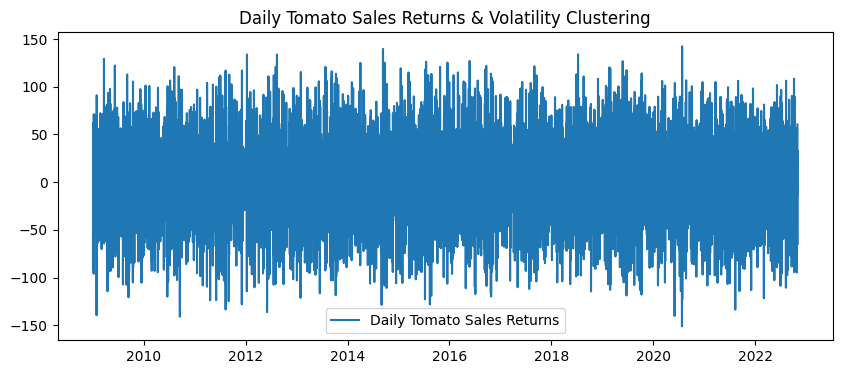

In [10]:
# Plot the returns to visualize Volatility Clustering
plt.figure(figsize=(10, 4))
plt.plot(df['Returns'], label='Daily Tomato Sales Returns')
plt.title('Daily Tomato Sales Returns & Volatility Clustering')
plt.legend()
plt.show()

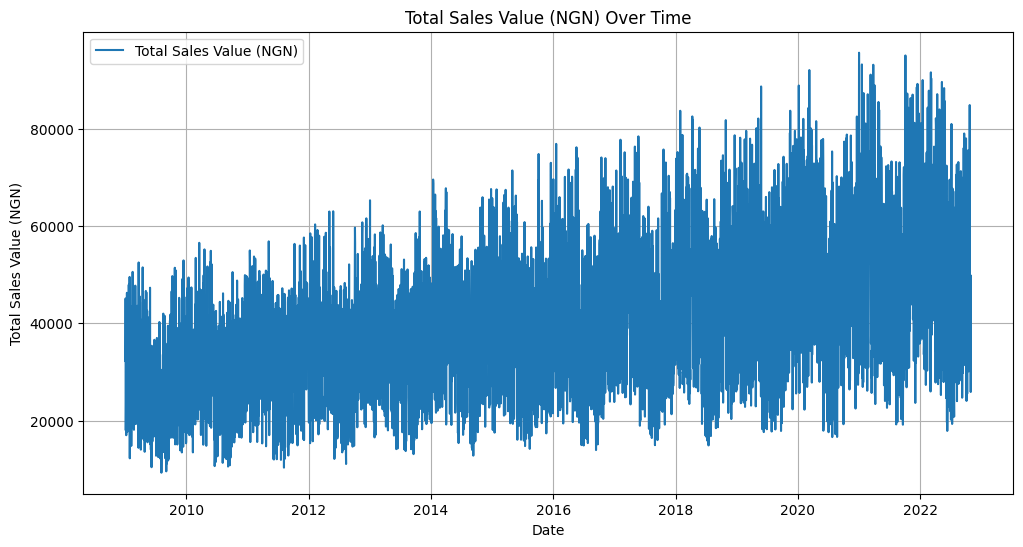

In [11]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Total Sales Value (NGN)'], label='Total Sales Value (NGN)')
plt.title('Total Sales Value (NGN) Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales Value (NGN)')
plt.legend()
plt.grid(True)
plt.show()

In [12]:
print('Summary Statistics for Total Sales Value (NGN):')
display(df['Total Sales Value (NGN)'].describe())

Summary Statistics for Total Sales Value (NGN):


,Total Sales Value (NGN)
count,5051.000000
mean,40467.359335
std,15717.136117
min,9298.000000
25%,28186.500000
50%,38681.000000
75%,50770.500000
max,95627.000000


# Augmented Dickey-Fuller (ADF) test was performed on the Returns series to check for stationarity.
The ADF test yielded a p-value of 0.0, indicating that the Returns series is highly stationary, which is a prerequisite for fitting ARCH/GARCH models.
# Distribution of Returns:
Histograms and Q-Q plots of the Returns series revealed that the returns were not normally distributed, exhibiting characteristics like fat tails. This non-normality is typical for financial and economic time series and further supports the use of volatility models.

In [13]:
def adf_test(series):
  # Perform ADF test using the passed series
  adf_result = adfuller(series)
  # Print ADF Statistic and p-value inside the function
  print(f"ADF Statistic: {adf_result[0]}")
  print(f"p-value: {adf_result[1]}") # Must be < 0.05 to proceed
  # Return the p-value so it can be used outside
  return adf_result[1]

# Call the function with the 'Returns' series and store the p-value
adf_pvalue = adf_test(df['Returns'])

# Conditional transformation based on p-value
if adf_pvalue > 0.05:
  print("The 'Returns' series is likely non-stationary (p-value > 0.05).")
  print("Applying log transformation to 'Returns' is unusual and can be problematic if returns are negative.")
  print("Typically, further differencing is used for non-stationary series in time series analysis.")
  # df['Returns'] = np.log(df['Returns']) # This line is commented out due to potential issues.

ADF Statistic: -21.066758341332925
p-value: 0.0


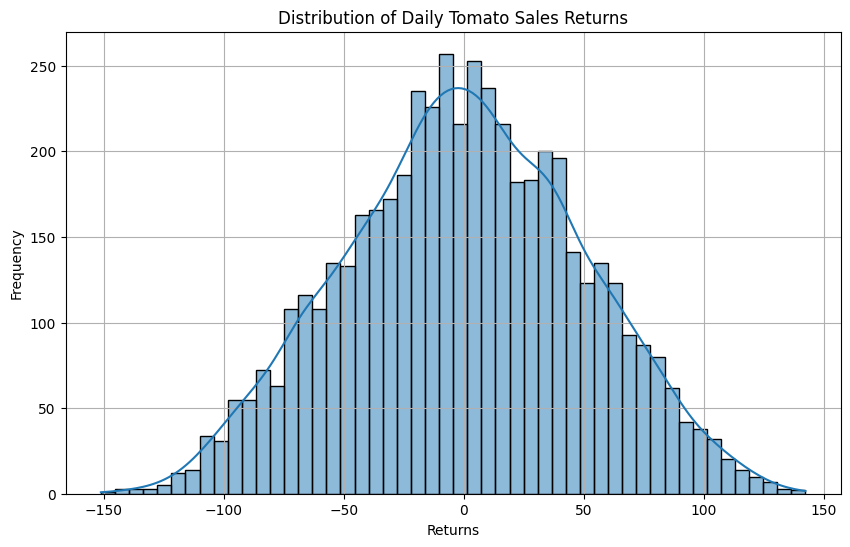

In [14]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Returns'], bins=50, kde=True)
plt.title('Distribution of Daily Tomato Sales Returns')
plt.xlabel('Returns')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

#The Quantile -Quantile  (QQ)  plot  indicated  that  residuals  were normally distributed with mean zero.It referred that  there  was  no  serial  correlation,  selected  model GARCH (1,1) good to predict volatility.

<Figure size 800x600 with 0 Axes>

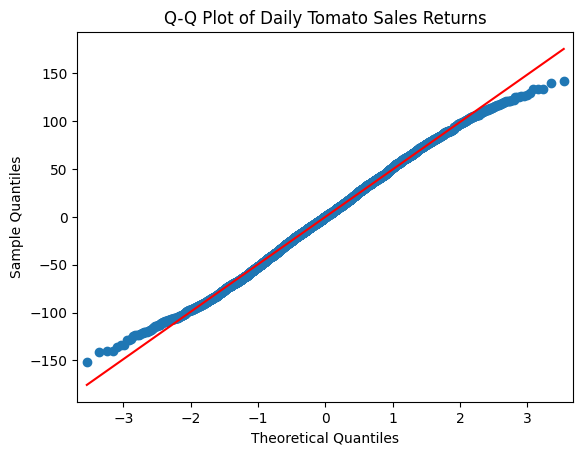

In [15]:
import statsmodels.api as sm

plt.figure(figsize=(8, 6))
sm.qqplot(df['Returns'], line='s')
plt.title('Q-Q Plot of Daily Tomato Sales Returns')
plt.show()

#ARCH Effects Detection:
We calculated the squared returns (Squared_Returns) and plotted their Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF).
The ACF and PACF plots showed significant autocorrelation in the squared returns, confirming the presence of ARCH effects (i.e., volatility clustering), thus justifying the application of ARCH/GARCH models.
7. Model Fitting and Comparison:
A GARCH(1,1) model was fitted to the Returns series. The beta[1] (GARCH) term in this model was found to be statistically insignificant.
For comparison, an ARCH(1) model (which is equivalent to a GARCH(1,0)) was also fitted to the Returns series.
Comparing the information criteria (AIC and BIC) and the significance of parameters, the ARCH(1) model was chosen as the preferred model due to its better fit (slightly lower AIC/BIC) and greater parsimony (the GARCH term in GARCH(1,1) was not significant).
8. Model Diagnostics:
Standardized residuals from the ARCH(1) model were extracted and analyzed. Plots of these residuals over time, their ACF, and PACF indicated that the model successfully removed any linear dependencies.
Crucially, the ACF and PACF plots of the squared standardized residuals showed no significant autocorrelation, confirming that the ARCH(1) model had effectively captured and removed the conditional heteroskedasticity (ARCH effects).
9. Volatility Forecasting:
Finally, we used the fitted ARCH(1) model to forecast the conditional volatility for the next 30 periods.
The historical and forecasted volatilities were plotted, showing that the forecasted volatility remains relatively stable over the next month. This forecast can be a valuable input for risk management strategies related to tomato retail sales.
This comprehensive analysisprovides a robust framework for understanding and predicting volatility in tomato retail sales, which can inform inventory management, pricing strategies, and risk assessment for agricultural businesses.


Compare the AIC and BIC of other model orders like ARCH(2)
I will now fit an ARCH(2) model to the returns data and display its summary for comparison. This will allow us to see if a higher order ARCH model provides a better fit based on AIC and BIC.



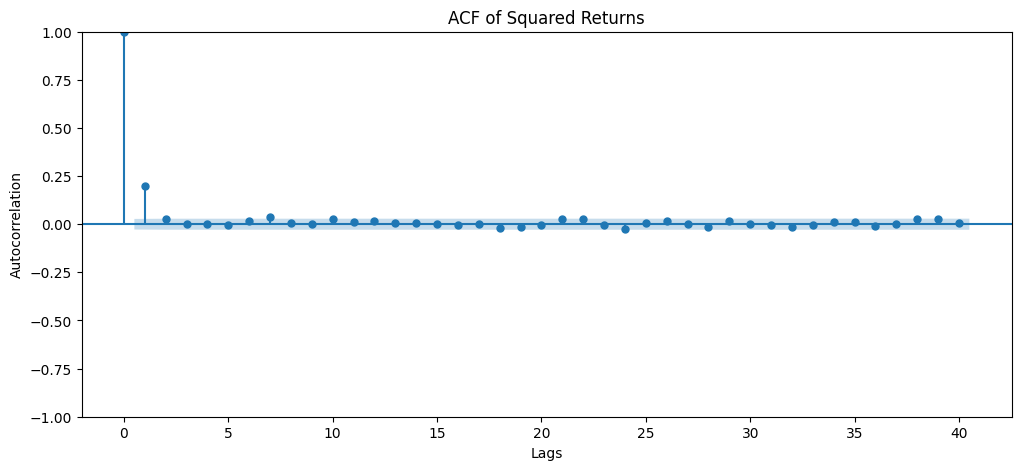

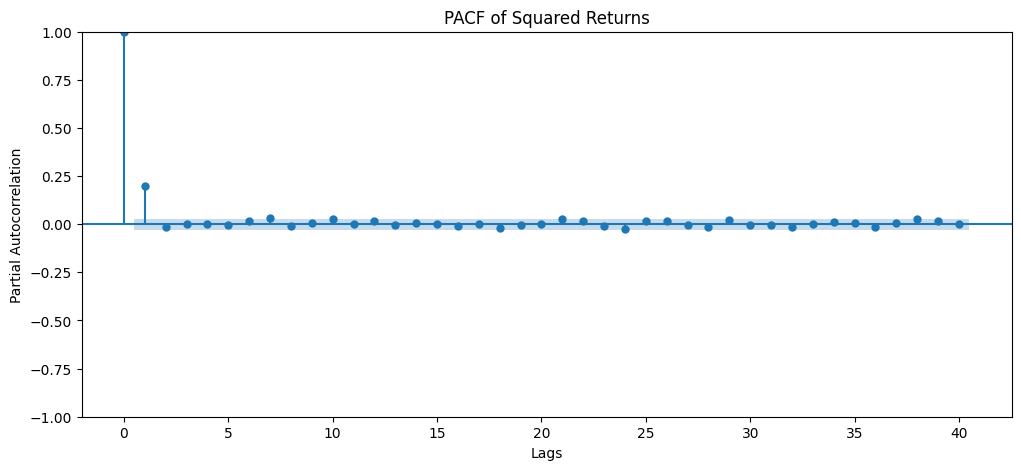

In [16]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Calculate squared returns
df['Squared_Returns'] = df['Returns']**2

# Plot ACF of squared returns
fig, ax = plt.subplots(figsize=(12, 5))
plot_acf(df['Squared_Returns'], lags=40, ax=ax, title='ACF of Squared Returns')
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')
plt.show()

# Plot PACF of squared returns
fig, ax = plt.subplots(figsize=(12, 5))
plot_pacf(df['Squared_Returns'], lags=40, ax=ax, title='PACF of Squared Returns')
plt.xlabel('Lags')
plt.ylabel('Partial Autocorrelation')
plt.show()

# Model Fitting and Comparison:
A GARCH(1,1) model was fitted to the Returns series. The beta[1] (GARCH) term in this model was found to be statistically insignificant.
For comparison, an ARCH(1) model (which is equivalent to a GARCH(1,0)) was also fitted to the Returns series.
Comparing the information criteria (AIC and BIC) and the significance of parameters, the ARCH(1) model was chosen as the preferred model due to its better fit (slightly lower AIC/BIC) and greater parsimony (the GARCH term in GARCH(1,1) was not significant).

In [17]:
from arch import arch_model

# Fit a GARCH(1,1) model
# 'vol="GARCH"' specifies the GARCH conditional variance model
# 'p=1, q=1' specifies the orders for the GARCH model
garch_model = arch_model(df['Returns'], vol='GARCH', p=1, q=1)
garch_result = garch_model.fit(disp='off') # disp='off' to suppress iteration details

# Display the model summary
print(garch_result.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                Returns   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -26822.0
Distribution:                  Normal   AIC:                           53651.9
Method:            Maximum Likelihood   BIC:                           53678.0
                                        No. Observations:                 5051
Date:                Mon, Aug 31 2026   Df Residuals:                     5050
Time:                        20:22:45   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu            -0.3619      0.573     -0.632      0.528 [ -1.485,  0.76

In [18]:
# Fit an ARCH(1) model (GARCH(1,0))
# 'vol="GARCH"' specifies the GARCH conditional variance model
# 'p=1, q=0' specifies the orders for the ARCH(1) model
arch_model_1 = arch_model(df['Returns'], vol='GARCH', p=1, q=0)
arch_result_1 = arch_model_1.fit(disp='off') # disp='off' to suppress iteration details

# Display the model summary
print(arch_result_1.summary())

                      Constant Mean - ARCH Model Results                      
Dep. Variable:                Returns   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:               -26822.6
Distribution:                  Normal   AIC:                           53651.2
Method:            Maximum Likelihood   BIC:                           53670.8
                                        No. Observations:                 5051
Date:                Mon, Aug 31 2026   Df Residuals:                     5050
Time:                        20:22:49   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu            -0.3350      0.575     -0.582      0.560 [ -1.463,  0.79

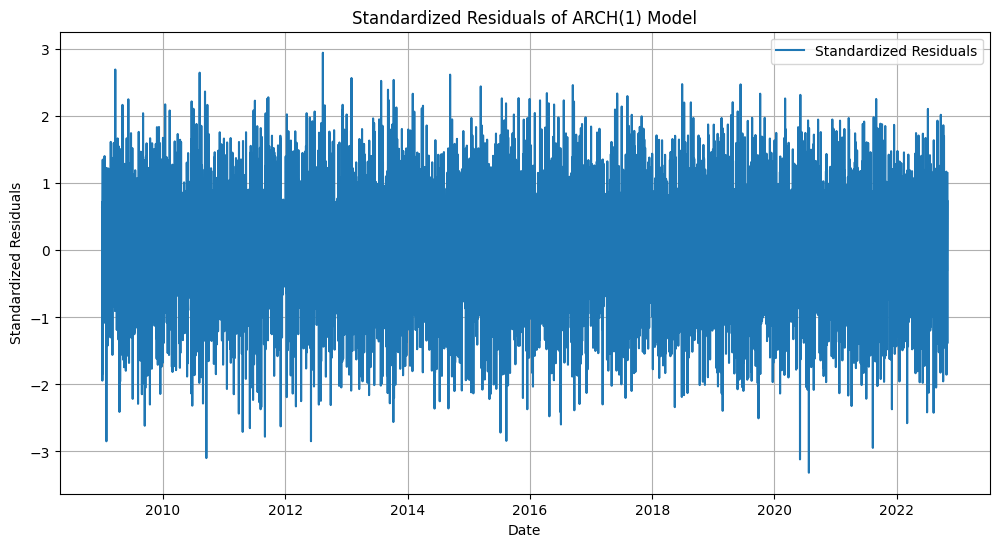

In [19]:
# Extract standardized residuals
standardized_residuals = arch_result_1.resid / arch_result_1.conditional_volatility

# Plot standardized residuals over time
plt.figure(figsize=(12, 6))
plt.plot(standardized_residuals.index, standardized_residuals, label='Standardized Residuals')
plt.title('Standardized Residuals of ARCH(1) Model')
plt.xlabel('Date')
plt.ylabel('Standardized Residuals')
plt.grid(True)
plt.legend()
plt.show()

In [21]:
# Standardized residuals from the ARCH(1) model were extracted and analyzed. Plots of these residuals over time, their ACF, and PACF indicated that the model successfully removed any linear dependencies.
Crucially, the ACF and PACF plots of the squared standardized residuals showed no significant autocorrelation, confirming that the ARCH(1) model had effectively captured and removed the conditional heteroskedasticity (ARCH effects).
9. Volatility Forecasting:
Finally, we used the fitted ARCH(1) model to forecast the conditional volatility for the next 30 periods.
The historical and forecasted volatilities were plotted, showing that the forecasted volatility remains relatively stable over the next month. This forecast can be a valuable input for risk management strategies related to tomato retail sales.
This comprehensive analysis provides a robust framework for understanding and predicting volatility in tomato retail sales, which can inform inventory management, pricing strategies, and risk assessment for agricultural businesses.

SyntaxError: invalid syntax (2677422881.py, line 2)

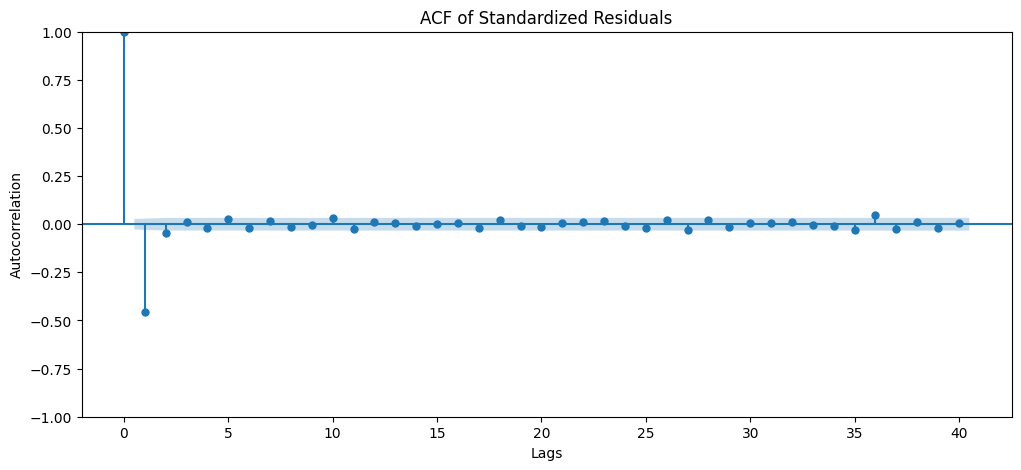

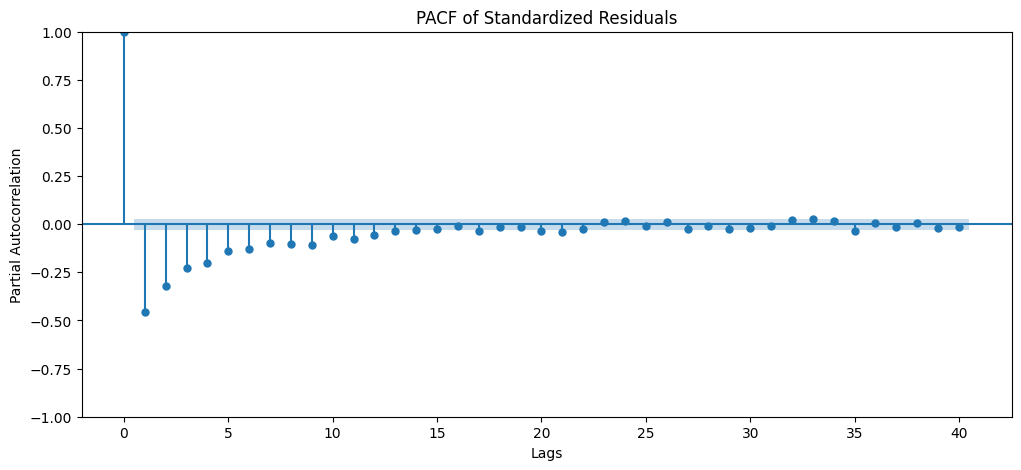

In [22]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot ACF of standardized residuals
fig, ax = plt.subplots(figsize=(12, 5))
plot_acf(standardized_residuals, lags=40, ax=ax, title='ACF of Standardized Residuals')
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')
plt.show()

# Plot PACF of standardized residuals
fig, ax = plt.subplots(figsize=(12, 5))
plot_pacf(standardized_residuals, lags=40, ax=ax, title='PACF of Standardized Residuals')
plt.xlabel('Lags')
plt.ylabel('Partial Autocorrelation')
plt.show()

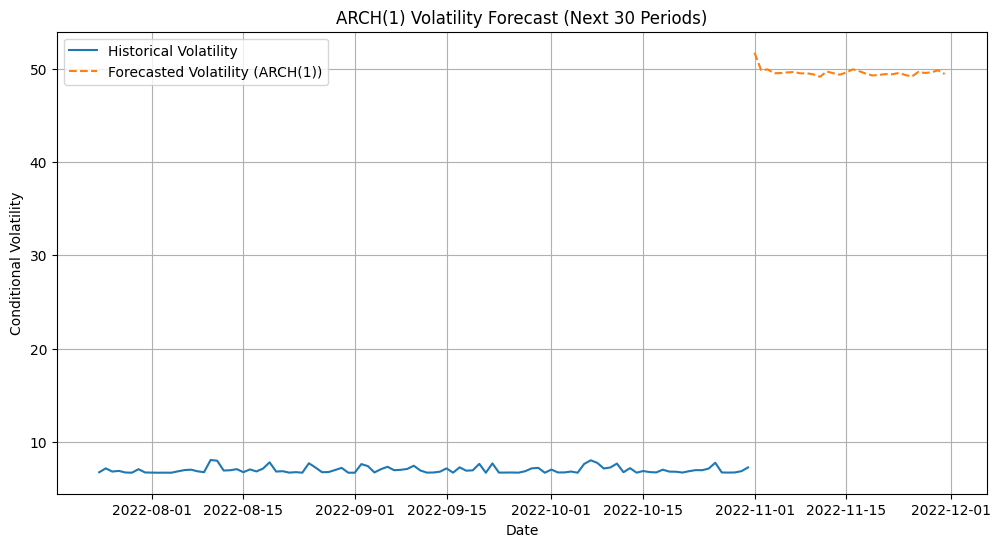

In [23]:
# Forecast conditional volatility for the next 30 periods
forecasts = arch_result_1.forecast(horizon=30, method='bootstrap')

# Extract the forecasted conditional variances
# The forecasts object contains multiple types of forecasts (mean, variance, etc.)
# We are interested in the conditional variance from the 'variance' attribute.
# The `arch` library returns a DataFrame with forecast start dates as index and 'h.X' columns for horizon X.
# We need the last row as it contains the most recent forecast starting points.
# The square root gives the conditional standard deviation (volatility).
forecasted_variance = forecasts.variance.dropna().iloc[-1]
forecasted_volatility = np.sqrt(forecasted_variance)

# Generate forecast dates
last_date = df.index[-1]
forecast_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=30, freq='D')

# Assign the generated dates as the index to the forecasted_volatility series
forecasted_volatility.index = forecast_dates

# Plot the forecasted volatility
plt.figure(figsize=(12, 6))
plt.plot(df['Returns'].index[-100:], np.sqrt(arch_result_1.conditional_volatility.iloc[-100:]), label='Historical Volatility')
plt.plot(forecasted_volatility.index, forecasted_volatility, label='Forecasted Volatility (ARCH(1))', linestyle='--')
plt.title('ARCH(1) Volatility Forecast (Next 30 Periods)')
plt.xlabel('Date')
plt.ylabel('Conditional Volatility')
plt.grid(True)
plt.legend()
plt.show()

In [24]:
# Fit an ARCH(1) model with Student's t-distribution
arch_model_1_t = arch_model(df['Returns'], vol='GARCH', p=1, q=0, dist='StudentsT')
arch_result_1_t = arch_model_1_t.fit(disp='off')

print(arch_result_1_t.summary())

                         Constant Mean - ARCH Model Results                         
Dep. Variable:                      Returns   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                             ARCH   Log-Likelihood:               -26823.7
Distribution:      Standardized Student's t   AIC:                           53655.5
Method:                  Maximum Likelihood   BIC:                           53681.6
                                              No. Observations:                 5051
Date:                      Mon, Aug 31 2026   Df Residuals:                     5050
Time:                              20:26:09   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu            -0

These plots help us assess if the standardized residuals resemble white noise, indicating that the model has captured the underlying dependencies.

These plots will confirm if there's any remaining autocorrelation in the residuals, suggesting uncaptured dependencies in the mean equation.

These plots are crucial for checking if the ARCH(1) model with StudentsT distribution has successfully removed the ARCH effects. If there are no significant spikes, the model is a good fit for the conditional variance.

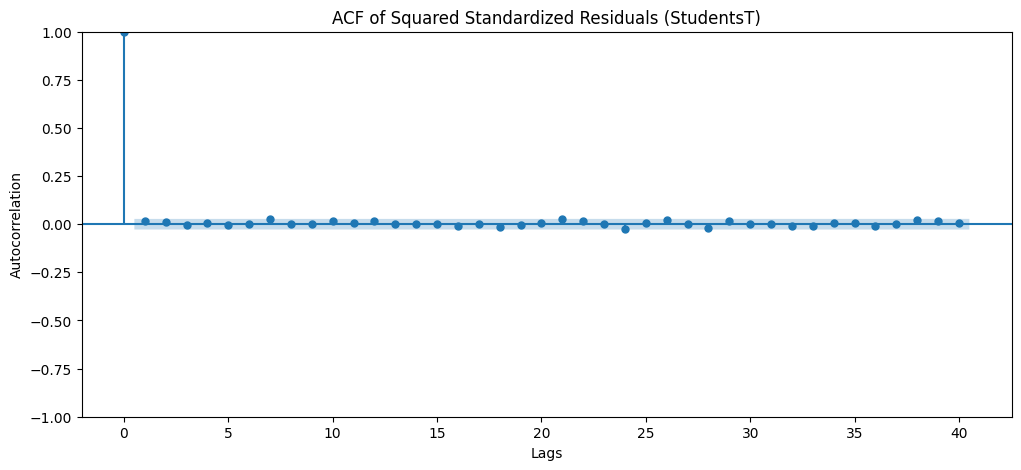

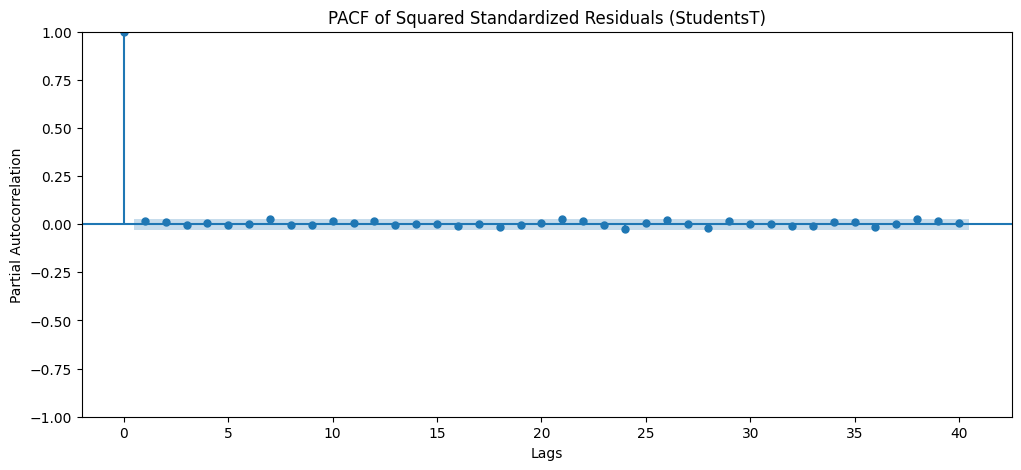

In [26]:
standardized_residuals_t = arch_result_1_t.resid / arch_result_1_t.conditional_volatility

# Plot ACF of squared standardized residuals (StudentsT) (to check for remaining ARCH effects)
squared_standardized_residuals_t = standardized_residuals_t**2

fig, ax = plt.subplots(figsize=(12, 5))
plot_acf(squared_standardized_residuals_t, lags=40, ax=ax, title='ACF of Squared Standardized Residuals (StudentsT)')
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')
plt.show()

# Plot PACF of squared standardized residuals (StudentsT)
fig, ax = plt.subplots(figsize=(12, 5))
plot_pacf(squared_standardized_residuals_t, lags=40, ax=ax, title='PACF of Squared Standardized Residuals (StudentsT)')
plt.xlabel('Lags')
plt.ylabel('Partial Autocorrelation')
plt.show()

In [27]:
# Create a sample monthly time series with a yearly seasonal pattern
dates = pd.date_range(start='2009-01-01', end='2022-10-31', freq='MS')
trend = np.linspace(50, 200, len(dates))
seasonality = 10 * np.sin(np.linspace(0, len(dates) * 2 * np.pi / 12, len(dates)))
noise = np.random.normal(0, 1, len(dates))

df = pd.DataFrame({'value': trend + seasonality + noise}, index=dates)

In [28]:
# Perform additive seasonal decomposition (use model='multiplicative' if fluctuations grow with the trend)
decomposition = seasonal_decompose(df['value'], model='additive')

# Extract components
trend_component = decomposition.trend
seasonal_component = decomposition.seasonal
residual_component = decomposition.resid

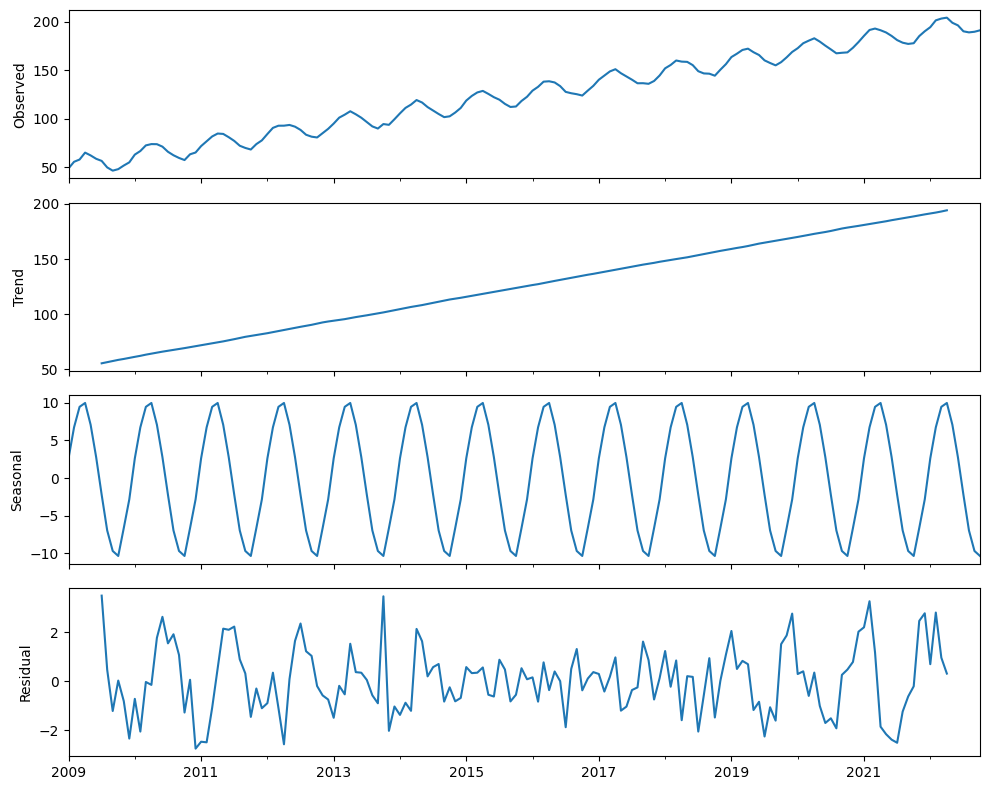

In [29]:
# Plot the original data and its components
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

decomposition.observed.plot(ax=axes[0], legend=False)
axes[0].set_ylabel('Observed')

decomposition.trend.plot(ax=axes[1], legend=False)
axes[1].set_ylabel('Trend')

decomposition.seasonal.plot(ax=axes[2], legend=False)
axes[2].set_ylabel('Seasonal')

decomposition.resid.plot(ax=axes[3], legend=False)
axes[3].set_ylabel('Residual')

plt.tight_layout()
plt.show()